In [43]:
# Import the Libraries required to work on this project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [44]:
# Write your code here
df = pd.read_csv('/content/sample_data_customer_transaction_data.csv')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_amount,currency,payment_method,transaction_status,customer_id,customer_first_name,customer_last_name,...,product_subcategory,quantity,item_price,discount_applied_percent,store_id,shipping_address_city,shipping_address_state,shipping_address_country,device_used,ip_address
0,b08a9d98-986e-41ec-989e-4acc5f43accb,2024-10-06,19:42:37,$885.57,USD,Debit Card,Failed,a027c0bd-1edf-4a3f-b7ef-f5c58d20b8d3,Cody,Carson,...,Author,10.0,$125.88,29.65,STORE-015,Robertsmouth,HI,Canada,Desktop,13.236.93.137
1,96f2f3b9-a3a5-493d-a09d-dc8875c6d704,2021-05-17,03:37:08,$906.74,USD,Debit Card,Refunded,eaf947f0-a685-4afc-800b-f4e62524b6fc,Rebecca,Crawford,...,Check,3.0,$384.05,21.30,STORE-005,Erinfort,MO,USA,Desktop,206.121.97.119
2,92a55669-dfe0-4edd-9770-2680c4aac6f6,2025-06-06,17:58:09,"$1,669.43",USD,credit_card,Refunded,47f33a62-e619-4aaf-a5c5-d4533f25e574,Heather,Mccall,...,End,7.0,$258.33,7.68,STORE-019,Nguyenburgh,MO,USA,Tablet,209.5.67.244
3,7dc592f6-c821-4318-8607-bf776147a910,2024-11-13,05:45:45,"$3,199.98",USD,Bank Transfer,Completed,195f9373-4509-4938-9c0f-8c809b7694a8,Douglas,Walsh,...,Lead,7.0,$477.48,4.26,STORE-009,New Ronaldview,MN,U.S.A.,Tablet,130.83.249.234
4,ad969b12-6f09-4a10-a911-90bc9f6953ad,2023-06-29,04:04:51,"$2,757.83",USD,Debit Card,Pending,0ed676db-664d-4ef8-8ce1-dc788f0c2bb7,Lisa,Stephenson,...,Glass,10.0,$372.63,25.99,STORE-020,South Mandy,FM,CAN,Tablet,191.67.255.253


| Column Name | Description | Potential Cleaning Issues |
| :--- | :--- | :--- |
| **transaction_id** | A unique identifier for each individual transaction. | Should be unique. Check for any duplicates. |
| **transaction_date** | The date the transaction occurred. | Should be parsed into a proper datetime format. |
| **transaction_time** | The time the transaction occurred. | Should be parsed into a proper time/datetime format. |
| **transaction_amount** | The total value of the transaction. | **String format** with `$` and commas. Must be converted to a numeric type (float). |
| **currency** | The currency used for the transaction. | Check for consistency (e.g., all USD). |
| **payment_method** | The method used for payment. | **Inconsistent naming** (e.g., "Credit Card", "credit_card", "CC"). Needs standardization. |
| **transaction_status** | The status of the transaction. | Check for any non-standard values. |
| **customer_id** | A unique identifier for each customer. | Check for any formatting issues. |
| **customer_first_name** | The first name of the customer. | General text cleaning may be needed. |
| **customer_last_name** | The last name of the customer. | General text cleaning may be needed. |
| **customer_email** | The customer's email address. | Check for invalid formats. |
| **customer_phone** | The customer's phone number. | **Inconsistent formats**. Needs parsing/standardization. |
| **customer_dob** | The customer's date of birth. | **Missing values (NaN)**. Should be parsed to datetime. |
| **customer_gender** | The gender of the customer. | **Missing values (NaN)** and may have inconsistent entries. |
| **account_creation_date**| The date the customer created their account. | Should be parsed into a proper datetime format. |
| **last_login_date** | The date of the customer's last login. | **Missing values (NaN)**. Should be parsed to datetime. |
| **loyalty_program_member**| Indicates if the customer is in the loyalty program. | **Mixed types** (e.g., TRUE/FALSE, 1/0). Needs to be standardized to a boolean type. |
| **product_id** | A unique identifier for each product. | Check for any formatting issues. |
| **product_name** | The name of the product purchased. | General text cleaning. |
| **product_category** | The main category of the product. | **Inconsistent capitalization and naming** (e.g., "Electronics", "electronics", "ELEC"). |
| **product_subcategory** | The sub-category of the product. | General text cleaning. |
| **quantity** | The number of units of the product purchased. | **Incorrect data type** (contains strings like 'N/A'). Must be converted to integer. |
| **item_price** | The price per unit of the product. | **String format** with '$' and commas. Must be converted to a numeric type (float). |
| **discount_applied_percent**| The discount percentage applied to the item. | Should be a numeric type. Check for outliers. |
| **store_id** | Identifier for the store (can represent different online channels). | Check for consistency. |
| **shipping_address_city** | The city where the order was shipped. | General text cleaning. |
| **shipping_address_state** | The state or province where the order was shipped. | **Missing values (NaN)**. |
| **shipping_address_country**| The country where the order was shipped. | **Inconsistent naming** (e.g., "USA", "United States", "U.S.A."). |
| **device_used** | The device used to make the transaction. | Check for consistency and standardize if needed. |
| **ip_address** | The IP address of the customer. | Check for invalid formats. |

---



In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            1030 non-null   object 
 1   transaction_date          1030 non-null   object 
 2   transaction_time          1030 non-null   object 
 3   transaction_amount        1030 non-null   object 
 4   currency                  1030 non-null   object 
 5   payment_method            1030 non-null   object 
 6   transaction_status        1030 non-null   object 
 7   customer_id               1030 non-null   object 
 8   customer_first_name       1030 non-null   object 
 9   customer_last_name        1030 non-null   object 
 10  customer_email            1030 non-null   object 
 11  customer_phone            1030 non-null   object 
 12  customer_dob              953 non-null    object 
 13  customer_gender           958 non-null    object 
 14  account_

In [46]:
# Columns where data type has to be changed
#  'loyalty_program_member',    -> Boolean         -> str


# Columns with missing values
# 'customer_gender'
#  'shipping_address_state',





In [47]:
# Describing the data
df.describe()

,quantity,discount_applied_percent
count,1007.000000,1030.000000
mean,5.556107,14.954767
std,3.992610,8.523191
min,1.000000,0.060000
25%,3.000000,7.970000
50%,5.000000,14.365000
75%,8.000000,22.462500
max,77.000000,29.980000


### **A. Data Cleaning and Preprocessing (Pandas & Core Python)**

1.  How many duplicate rows are there in the dataset? Write the code to remove them.

In [48]:
df.duplicated().count()

np.int64(1030)

In [49]:
print(f'Number of rows before removing duplicates:- {len(df)}')
num_duplicates = df.duplicated().sum()      # duplicated() method gives us to tal count of True Duplicates (All column values for the duplicated rows are same)
print(f'Number of duplicate rows found is {num_duplicates}')

Number of rows before removing duplicates:- 1030
Number of duplicate rows found is 30


In [50]:
# Code for removing the
df.drop_duplicates(inplace = True)
print(f'Number of rows after removing duplicates:- {len(df)}')

Number of rows after removing duplicates:- 1000


2.  Identify all columns that have missing values and calculate the percentage of missing values for each.


In [51]:
missing_values = df.isnull().sum()
print(f'Total number of missing values \n{missing_values[missing_values>0]}')

Total number of missing values 
customer_dob              77
customer_gender           71
last_login_date           73
quantity                  23
shipping_address_state    65
dtype: int64


In [52]:
missing_percentage = (missing_values / len(df)) * 100
print(f'Total percentage of missing values \n{missing_percentage[missing_percentage>0]}')

Total percentage of missing values 
customer_dob              7.7
customer_gender           7.1
last_login_date           7.3
quantity                  2.3
shipping_address_state    6.5
dtype: float64


3.  Devise a strategy to handle the missing values in `customer_dob` and `last_login_date`. Implement it.


In [53]:
# Converting transaction_date, account_creation_date, customer_dob, last_login_date into datetime object
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['account_creation_date'] = pd.to_datetime(df['account_creation_date'])
df['customer_dob'] = pd.to_datetime(df['customer_dob'])
df['last_login_date'] = pd.to_datetime(df['last_login_date'])

In [54]:
# TO check if transaction_date is last_login_date in case of any transaction
ser = (df['last_login_date'] == df['transaction_date'])
np.where(ser == True)


# Strategy for last_login_date: Fill missing with account_creation_date
df['last_login_date'] = df['last_login_date'].fillna(df['account_creation_date'])

In [55]:
# Not filling missing value in customer_dob with any random value as it is not good to predict someone's DoB

print("Missing values after handling customer_dob and last_login_date:")
print(df[['customer_dob', 'last_login_date']].isnull().sum())

Missing values after handling customer_dob and last_login_date:
customer_dob       77
last_login_date     0
dtype: int64


4.  The `transaction_amount` and `item_price` columns are strings. Convert them into a numeric format (float).


In [56]:
print('Data types before conversion: ')
print(df[['transaction_amount', 'item_price']].dtypes)

df[['transaction_amount', 'item_price']].sample(n = 10)

Data types before conversion: 
transaction_amount    object
item_price            object
dtype: object


,transaction_amount,item_price
661,"$1,545.34",$223.60
355,$487.59,$63.25
1022,$68.23,$24.13
845,"$1,118.44",$284.59
712,$360.34,$490.19
619,"$1,248.08",$484.09
138,$342.84,$162.79
808,"$1,746.53",$351.52
412,$98.15,$114.82
70,$985.08,$280.97


In [57]:
df['transaction_amount'] = df['transaction_amount'].replace({r'[$,]':''}, regex = True).astype(float)
df['item_price'] = df['item_price'].replace({r'[$,]':''}, regex = True).astype(float)

print('Data types after conversion: ')
print(df[['transaction_amount', 'item_price']].dtypes)

Data types after conversion: 
transaction_amount    float64
item_price            float64
dtype: object


5.  The `quantity` column has non-numeric values like 'N/A'. Identify these rows and replace the values with the median quantity of the dataset.


In [58]:
print("Quantity column unique values before cleaning:")
print(df['quantity'].value_counts(dropna = False))

Quantity column unique values before cleaning:
quantity
7.0     122
3.0     105
1.0      98
9.0      97
2.0      97
4.0      96
6.0      96
5.0      96
8.0      87
10.0     81
NaN      23
60.0      1
77.0      1
Name: count, dtype: int64


'NA' -> NaN

In [59]:
# Identify non-numeric values and convert to NaN
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

# Calculate the median quantity (excluding NaN values)
median_quantity = df['quantity'].median()

# Fill missing values with the median quantity
df['quantity'] = df['quantity'].fillna(median_quantity)

# Convert quantity to integer type
df['quantity'] = df['quantity'].astype(int)

print(df['quantity'].dtypes)

int64


6.  Clean the `product_category` column by standardizing all entries to a consistent format (e.g., Title Case).


In [60]:
print("Unique values in 'product_category' before standardization:")
print(df['product_category'].unique())

Unique values in 'product_category' before standardization:
['electronics' 'BEAUTY' 'Beauty' 'Books' 'home goods' 'Apparel'
 'Home Goods' 'ELEC' 'apparel' 'books' 'Electronics']


In [61]:
df['product_category'] = df['product_category'].str.title()
print("Unique values in 'product_category' after standardization:")
print(df['product_category'].unique())

Unique values in 'product_category' after standardization:
['Electronics' 'Beauty' 'Books' 'Home Goods' 'Apparel' 'Elec']


In [62]:
df['product_category'] = df['product_category'].replace('Elec', 'Electronics')
print("Unique values in 'product_category' after standardization:")
print(df['product_category'].unique())

Unique values in 'product_category' after standardization:
['Electronics' 'Beauty' 'Books' 'Home Goods' 'Apparel']


7.  Standardize the `payment_method` column to have only three distinct values: 'Credit Card', 'PayPal', 'Bank Transfer'.


In [63]:
print("Unique values in 'payment_method' before standardization:")
print(df['payment_method'].unique())

Unique values in 'payment_method' before standardization:
['Debit Card' 'credit_card' 'Bank Transfer' 'paypal' 'PayPal'
 'Credit Card' 'CC']


In [64]:
df['payment_method']=df['payment_method'].replace({
    'Credit Card': 'Credit Card',
    'CC' : 'Credit Card',
    'Debit Card': 'Credit Card',
    'credit_card': 'Credit Card',
    'Bank Transfer':'Bank Transfer',
    'bank_transfer':'Bank Transfer',
    'PayPal':'PayPal',
    'paypal':'PayPal'
})

print("Unique values in 'payment_method' after standardization:")
print(df['payment_method'].unique())

Unique values in 'payment_method' after standardization:
['Credit Card' 'Bank Transfer' 'PayPal']


8.  Parse the `customer_phone` numbers to a standard E.164 format (e.g., +1XXXXXXXXXX). (This is a complex core python/regex task).



In [65]:
print("Unique values in 'customer_phone' before standardization (first 5):")
print(df['customer_phone'].head(n = 15))

Unique values in 'customer_phone' before standardization (first 5):
0        430.560.9453x2052
1       984.604.4150x43467
2            (430)785-7136
3        742-777-1185x4779
4        (746)790-3735x459
5     001-842-261-7325x122
6       (648)969-4686x5275
7        (556)996-6659x782
8             712-308-0106
9       262.292.3564x21820
10            414.713.8295
11         +1-676-895-5724
12    +1-628-905-0465x8103
13       530.206.5634x5997
14     +1-209-732-2278x978
Name: customer_phone, dtype: object


In [66]:
import re

def standardize_phone(phone_number):
  if pd.isna(phone_number):
    return None

  # Remove non-digit characters
  digits = re.sub(r'\D', '', str(phone_number))

  # Handle common patterns and convert to E.164
  if len(digits) == 10: # Assuming it is US number
    return '+1' + digits
  elif len(digits) == 11 and digits.startswith('1'):
    return '+' + digits
  elif len(digits) > 11:
    if digits.startswith('00'):
      return '+' + digits[2:]
    if not digits.startswith('+'):
      return '+'+digits
  return str(phone_number)

df['customer_phone'] = df['customer_phone'].apply(standardize_phone)
print("Unique values in 'customer_phone' after standardization (first 5):")
print(df['customer_phone'].sample(n= 15))

Unique values in 'customer_phone' after standardization (first 5):
775       +2782672212727
557         +15692600159
931      +71791966767569
397     +146238813350917
257         +16946762642
174     +378671161881574
840     +180337531789551
950    +1865420998180963
669         +15949956761
792     +459914040960201
265    +1325858140395015
341      +16867124812692
900    +1840569408638038
766         +15092505525
628    +1633553754584016
Name: customer_phone, dtype: object


### EDA


9.  What is the overall distribution of `transaction_amount`? Plot a histogram and a boxplot and interpret the outliers.

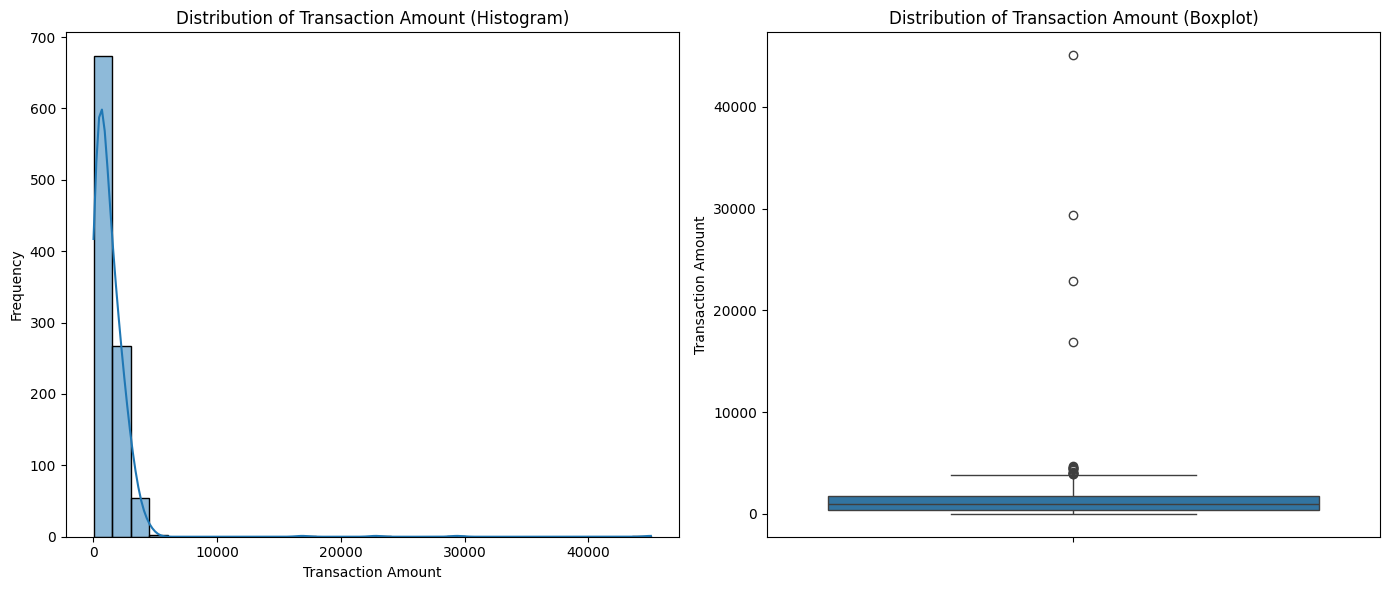

Statistical Summary of Transaction Amount:
count     1000.000000
mean      1302.314480
std       2091.339933
min          4.300000
25%        380.445000
50%        945.100000
75%       1786.642500
max      45066.670000
Name: transaction_amount, dtype: float64

Number of outliers based on IQR: 17
Percentage of outliers: 1.70%


In [67]:
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['transaction_amount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amount (Histogram)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['transaction_amount'])
plt.title('Distribution of Transaction Amount (Boxplot)')
plt.ylabel('Transaction Amount')

plt.tight_layout()
plt.show()

# Describe to get statistical summary
print("Statistical Summary of Transaction Amount:")
print(df['transaction_amount'].describe())

# Identify potential outliers using IQR method
# Interquartile Range(IQR) = Q3 - Q1

Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)
# print(Q1)
# print(Q3)
IQR = Q3-Q1

upper_bound = Q3 + (1.5 * IQR)
lower_bound = Q1 - (1.5 * IQR)

outliers = df[(df['transaction_amount'] < lower_bound) | (df['transaction_amount'] > upper_bound)]
print(f"\nNumber of outliers based on IQR: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(df) * 100:.2f}%")

In [68]:
# https://www.amazon.in/Machine-Learning-Science-Using-Python/dp/9391540465

# Machine Learning for Absolute Beginners - Oliver Theobald

# https://www.oreilly.com/library/view/essential-math-for/9781098102920/

# Naked Statistics - Charles Wheelan

10. Which are the top 10 best-selling products by total quantity sold? Create a bar chart.


In [69]:
# df['product_name'].unique()

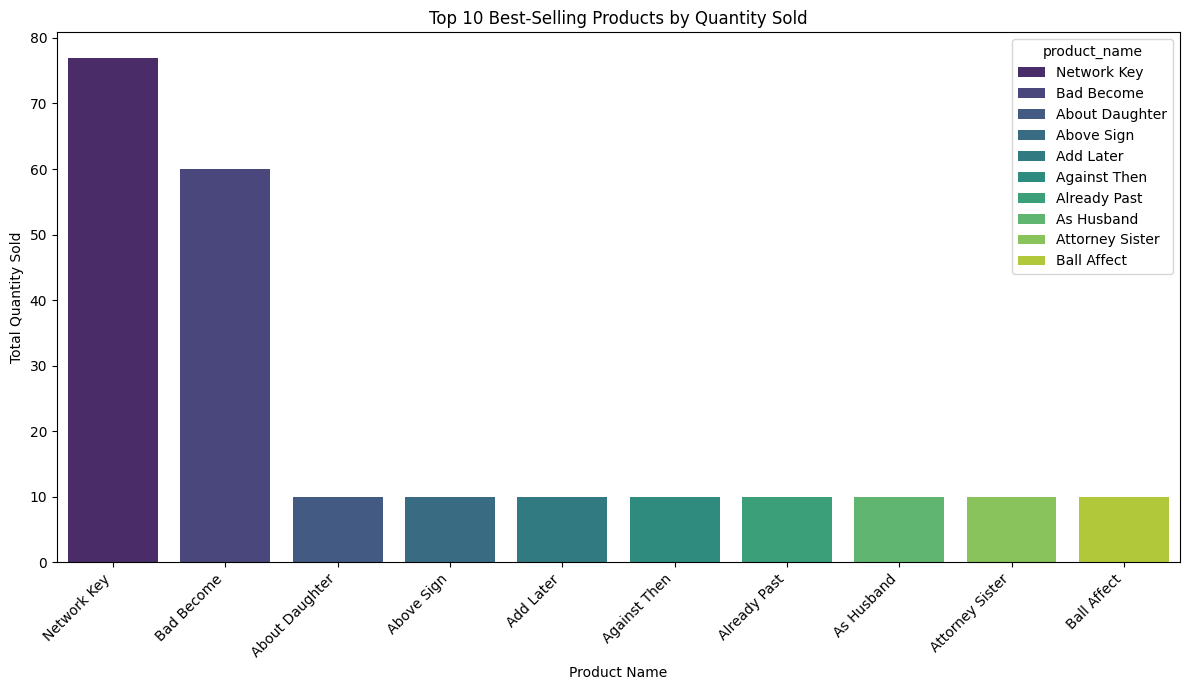

In [70]:
top_10_products = df.groupby('product_name')['quantity'].sum().nlargest(10)
top_10_products

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_products.index, y=top_10_products.values, palette='viridis', hue=top_10_products.index, legend=True)
plt.title('Top 10 Best-Selling Products by Quantity Sold')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

11. How do sales vary by `day_of_week` and `month`? (Requires feature engineering first). Create appropriate visualizations.


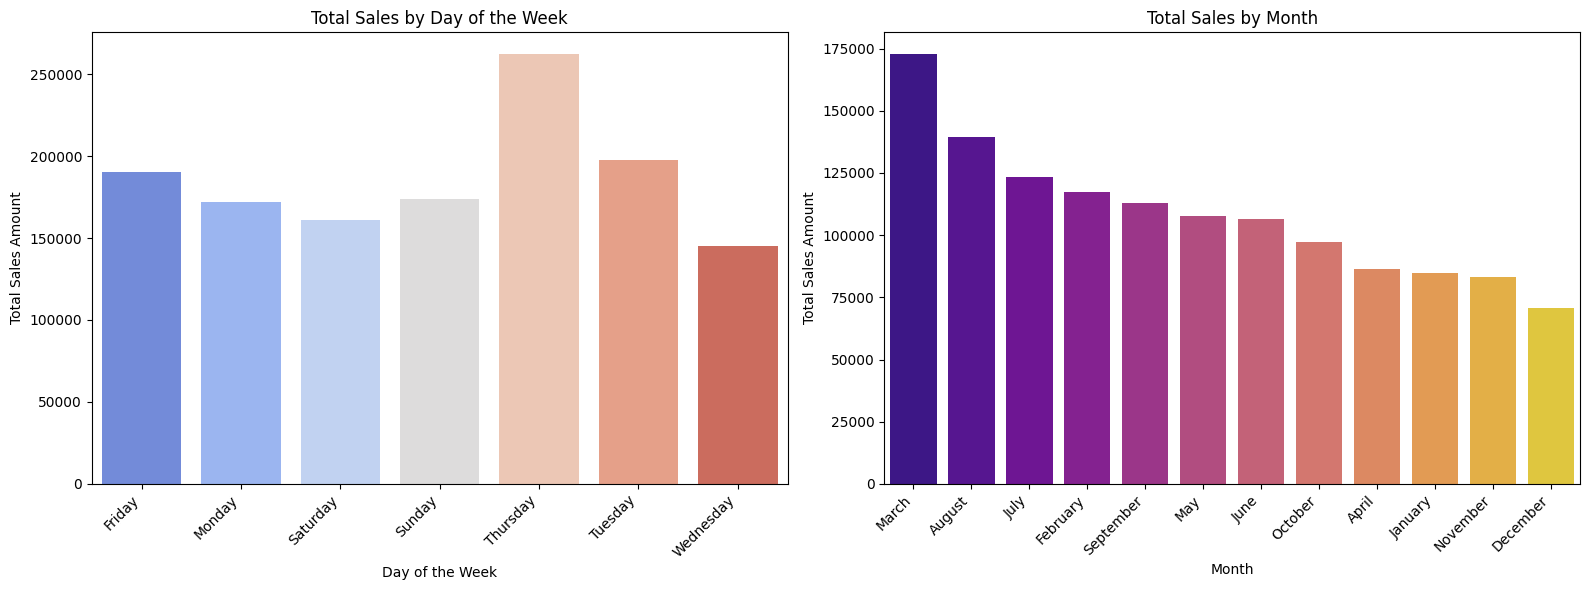

In [71]:
# Extract day of the week and month from transaction_date
df['transaction_day_of_week'] = df['transaction_date'].dt.day_name()
df['transaction_month'] = df['transaction_date'].dt.month_name()

# df.info()
# df['transaction_day_of_week'].head()
# df['transaction_month'].head()

# Group by day of week and sum transaction amounts
sales_by_day = df.groupby('transaction_day_of_week')['transaction_amount'].sum()


sales_by_month = df.groupby('transaction_month')['transaction_amount'].sum().sort_values(ascending = False)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='coolwarm', hue=sales_by_day.index, legend=False)
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=sales_by_month.index, y=sales_by_month.values, palette='plasma', hue=sales_by_month.index, legend=False)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


12. What is the most common `payment_method`? Visualize the proportions using a pie chart.


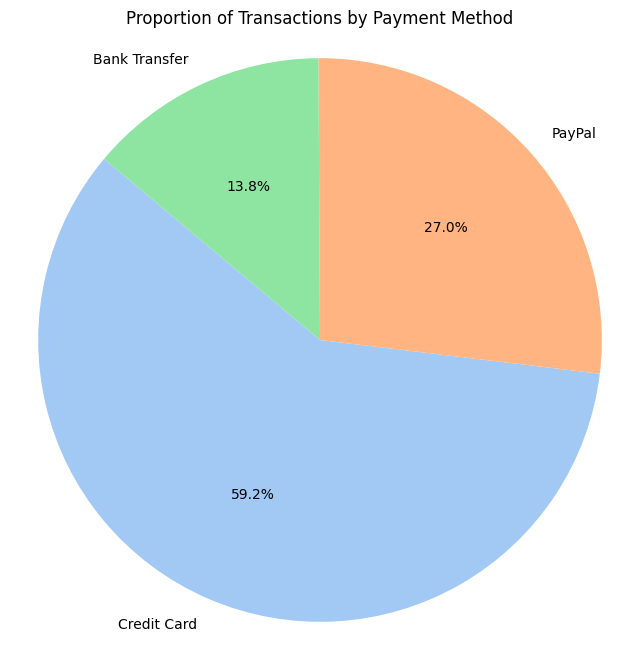

In [72]:
payment_method_counts = df['payment_method'].value_counts()
payment_method_counts

plt.figure(figsize=(8, 8))
plt.pie(payment_method_counts, labels=payment_method_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Transactions by Payment Method')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

13. Show the distribution of transactions across different `shipping_address_state`s using a bar chart.


In [73]:
# df['shipping_address_state'].unique()

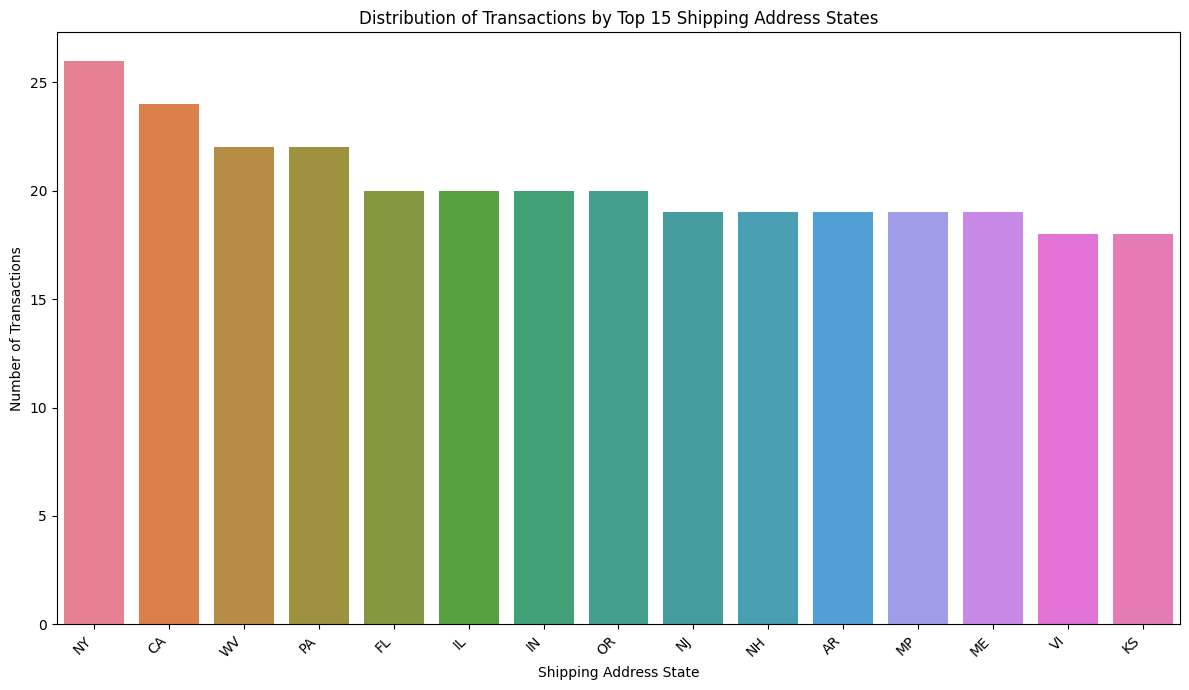

In [74]:
state_counts = df['shipping_address_state'].value_counts().nlargest(15)
state_counts

plt.figure(figsize=(12, 7))
sns.barplot(x=state_counts.index, y=state_counts.values, hue=state_counts.index, legend=False)
plt.title('Distribution of Transactions by Top 15 Shipping Address States')
plt.xlabel('Shipping Address State')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

14. Is there a correlation between `item_price`, `quantity`, and `discount_applied_percent`? Calculate the correlation matrix and visualize it as a heatmap.


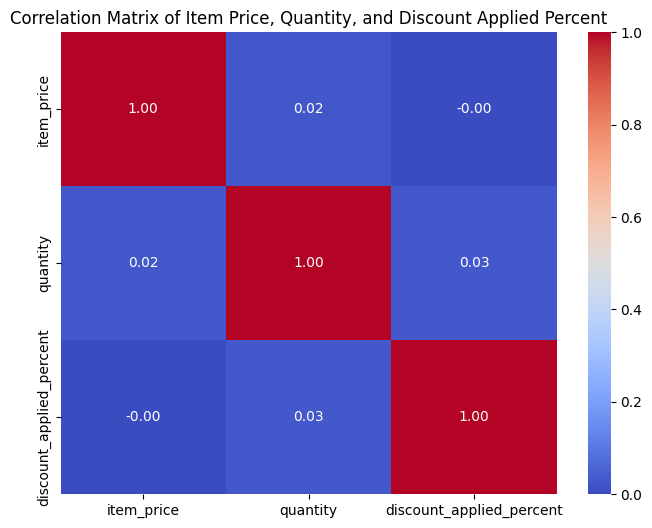

In [75]:
correlation_matrix = df[['item_price', 'quantity', 'discount_applied_percent']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Item Price, Quantity, and Discount Applied Percent')
plt.show()

15. Compare the average transaction amount across different devices (`device_used`) using a bar chart or boxplot.



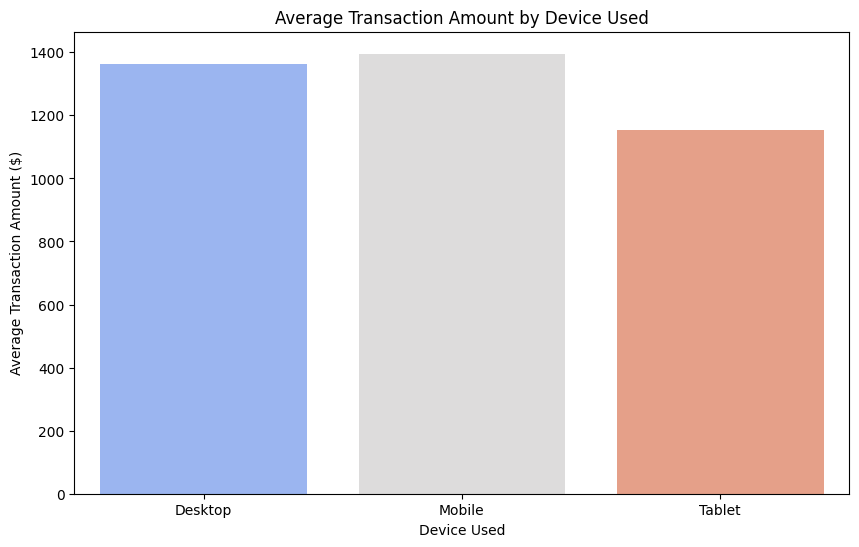

In [76]:
avg_transaction_by_device = df.groupby('device_used')['transaction_amount'].mean()
avg_transaction_by_device

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_transaction_by_device.index, y=avg_transaction_by_device.values, palette='coolwarm', hue=avg_transaction_by_device.index, legend=False)
plt.title('Average Transaction Amount by Device Used')
plt.xlabel('Device Used')
plt.ylabel('Average Transaction Amount ($)')
plt.show()

### **C. Feature Engineering (Pandas & NumPy)**

16. Create a `customer_age` column by calculating the age from `customer_dob`.

In [77]:
current_date = pd.to_datetime('today')
df['customer_age'] = (current_date.year - df['customer_dob'].dt.year) \
                          - ((current_date.month < df['customer_dob'].dt.month) | \
                             ((current_date.month == df['customer_dob'].dt.month) & (current_date.day < df['customer_dob'].dt.day)))

# current_date = 17-08-2026
# customer_dob = 20-08-2000
# customer_age = 26 - (True) = 26-1 = 25
# customer_age = 26 - ((8<6) | ((8 == 6) & ())) = 26 - False = 26
# customer_age = 26 - ((8<8) | ((8 == 8) & (17<17))) = 26 - False = 26
# customer_age = 26 - ((8<8) | ((8 == 8) & (17<20))) = 26 - (False | True) = 26 - True = 26 - 1 = 25

print("Customer Age created. First 5 values:")
print(df['customer_age'].head())
print(f"Number of missing customer ages: {df['customer_age'].isnull().sum()}")

Customer Age created. First 5 values:
0    45.0
1    43.0
2    24.0
3    85.0
4    49.0
Name: customer_age, dtype: float64
Number of missing customer ages: 77


17. Create a `transaction_day_of_week` column from the `transaction_date`.


18. Create a `customer_tenure_days` column (days since `account_creation_date` to the transaction date).


In [78]:
df['customer_tenure_days'] = (df['transaction_date'] - df['account_creation_date']).dt.days

print("Customer Tenure (days) created. First 5 values:")
print(df['customer_tenure_days'].head())
print(f"Statistical summary of customer_tenure_days:\n{df['customer_tenure_days'].describe()}")

Customer Tenure (days) created. First 5 values:
0    292
1    113
2    870
3    634
4    108
Name: customer_tenure_days, dtype: int64
Statistical summary of customer_tenure_days:
count    1000.000000
mean      531.709000
std       396.849389
min         0.000000
25%       207.000000
50%       444.500000
75%       791.250000
max      1773.000000
Name: customer_tenure_days, dtype: float64


In [79]:
# df

19. Create a `total_spend_per_customer` feature that aggregates all transaction amounts for each `customer_id`.


In [80]:
total_spend_per_customer = df.groupby('customer_id')['transaction_amount'].sum().reset_index()
# total_spend_per_customer
total_spend_per_customer.rename(columns={'transaction_amount': 'total_spend'}, inplace=True)
total_spend_per_customer

df = df.merge(total_spend_per_customer, on='customer_id', how='left')

print("Total Spend Per Customer (first 5 unique customers):")
print(total_spend_per_customer.head())
print(f"Statistical summary of total_spend_per_customer:\n{df['total_spend'].describe()}")

Total Spend Per Customer (first 5 unique customers):
                            customer_id  total_spend
0  01300d38-4216-4beb-92c3-a605610157b9     11666.21
1  015fbd46-c368-4c33-98f6-a45b37b1f924     15441.89
2  06f3735d-b8b7-46d2-9bae-9993a2fb18be      8966.11
3  085f3175-bd80-4ad2-9139-28ed337eef69      2995.47
4  0aa8aa4c-540b-4377-ac3d-c60c26a6d0ba     18737.39
Statistical summary of total_spend_per_customer:
count     1000.000000
mean     14365.825310
std       7253.085128
min        736.380000
25%      10662.780000
50%      12961.115000
75%      16727.770000
max      54005.020000
Name: total_spend, dtype: float64


20. Engineer a `days_since_last_login` feature based on the transaction date and the `last_login_date`.


In [81]:
df['days_since_last_login'] = (df['transaction_date'] - df['last_login_date']).dt.days

print("Days Since Last Login created. First 5 values:")
print(df['days_since_last_login'].head())
print(f"Statistical summary of days_since_last_login:\n{df['days_since_last_login'].describe()}")

Days Since Last Login created. First 5 values:
0    55
1     6
2    36
3    27
4    17
Name: days_since_last_login, dtype: int64
Statistical summary of days_since_last_login:
count    1000.000000
mean       80.262000
std       172.029159
min         1.000000
25%        24.000000
50%        49.000000
75%        72.250000
max      1773.000000
Name: days_since_last_login, dtype: float64


21. Create a categorical feature `price_tier` for items based on `item_price` (e.g., 'Low', 'Medium', 'High').



In [82]:
# low -> (0-50] -> 50 is inclusive when right is True
# med -> (50 -200] 0> 200 is inclusive when right = True
# High -> (200 - Max]

# (a, b) -> a and b both are not inclusive
# [a, b] -> a and b both are  inclusive
# (a, b] -> a is not inclusive and b is inclusive
# [a, b) -> a is inclusive and b is not inclusive

In [83]:
bins = [0, 50, 200, df['item_price'].max()]
labels = ['Low', 'Medium', 'High']

df['price_tier'] = pd.cut(df['item_price'], bins=bins, labels=labels, right=False)

print("Price Tier created. Value counts:")
print(df['price_tier'].value_counts())
print(f"First 5 values of price_tier:\n{df['price_tier'].head()}")


Price Tier created. Value counts:
price_tier
High      630
Medium    281
Low        88
Name: count, dtype: int64
First 5 values of price_tier:
0    Medium
1      High
2      High
3      High
4      High
Name: price_tier, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


### **D. Advanced Analysis & Business Insights**

22. Who are the top 10% of customers by `total_spend_per_customer`? Analyze their characteristics (e.g., common product categories, preferred device).


In [84]:
top_10_percent_spend_threshold = df['total_spend'].quantile(0.90)
richest_customers = df[df['total_spend'] >= top_10_percent_spend_threshold]

print(f"Threshold for top 10% of customers by total spend: ${top_10_percent_spend_threshold:.2f}")
print(f"Number of transactions made by top 10% customers: {len(richest_customers)}")
print(f"Number of unique top 10% customers: {richest_customers['customer_id'].nunique()}")

Threshold for top 10% of customers by total spend: $21551.10
Number of transactions made by top 10% customers: 109
Number of unique top 10% customers: 8


In [85]:
print("\nCommon Product Categories among Top 10% Customers:")
print(richest_customers['product_category'].value_counts(normalize=True).head())


Common Product Categories among Top 10% Customers:
product_category
Electronics    0.293578
Books          0.201835
Apparel        0.201835
Beauty         0.165138
Home Goods     0.137615
Name: proportion, dtype: float64


In [86]:
# Analyze preferred device
print("\nPreferred Devices among Top 10% Customers:")
print(richest_customers['device_used'].value_counts(normalize=True).head())


Preferred Devices among Top 10% Customers:
device_used
Mobile     0.339450
Desktop    0.339450
Tablet     0.321101
Name: proportion, dtype: float64


In [87]:
# Analyze average transaction amount
print("\nAverage Transaction Amount among Top 10% Customers:")
print(richest_customers['transaction_amount'].mean())


Average Transaction Amount among Top 10% Customers:
2210.0579816513764


In [88]:
# Analyze average customer age
print("\nAverage Customer Age among Top 10% Customers:")
print(richest_customers['customer_age'].mean())


Average Customer Age among Top 10% Customers:
57.490196078431374


In [89]:
# Analyze loyalty program membership
print("\nLoyalty Program Membership among Top 10% Customers (proportion):")
print(richest_customers['loyalty_program_member'].value_counts(normalize=True))


Loyalty Program Membership among Top 10% Customers (proportion):
loyalty_program_member
0        0.284404
False    0.266055
1        0.247706
True     0.201835
Name: proportion, dtype: float64


23. Does being a `loyalty_program_member` have a significant impact on the average transaction amount? Perform a comparative analysis.


In [90]:
# First, ensure loyalty_program_member is consistent (e.g., boolean)
# Create a temporary series to ensure we are working with the original values as much as possible
temp_loyalty = df['loyalty_program_member'].copy()

# Convert all values in the temporary series to string lower case for consistent mapping
temp_loyalty = temp_loyalty.astype(str).str.lower()

# Assign True for 'true' or '1', and False for 'false' or '0'. All other values will default to False.
# Use np.select for explicit condition handling

conditions = [
    temp_loyalty.isin(['true', '1']),
    temp_loyalty.isin(['false', '0'])
]

choices = [True, False]

df['loyalty_program_member'] = np.select(conditions, choices, default=False)

df['loyalty_program_member'].value_counts(normalize=True)

,proportion
loyalty_program_member,
False,0.506
True,0.494


In [91]:
print("\nLoyalty Program Membership among Top 10% Customers (proportion):")
print(richest_customers['loyalty_program_member'].value_counts(normalize=True))


Loyalty Program Membership among Top 10% Customers (proportion):
loyalty_program_member
0        0.284404
False    0.266055
1        0.247706
True     0.201835
Name: proportion, dtype: float64


In [92]:
# Ensure the column is of boolean dtype
df['loyalty_program_member'] = df['loyalty_program_member'].astype(bool)

print("Value counts of loyalty_program_member after standardization for Question 23:")
print(df['loyalty_program_member'].value_counts())

Value counts of loyalty_program_member after standardization for Question 23:
loyalty_program_member
False    506
True     494
Name: count, dtype: int64


In [93]:
# Group by loyalty program membership and calculate the average transaction amount
avg_transaction_by_loyalty = df.groupby('loyalty_program_member')['transaction_amount'].mean()

print("\nAverage Transaction Amount by Loyalty Program Membership:")
print(avg_transaction_by_loyalty)


Average Transaction Amount by Loyalty Program Membership:
loyalty_program_member
False    1327.425711
True     1276.593259
Name: transaction_amount, dtype: float64


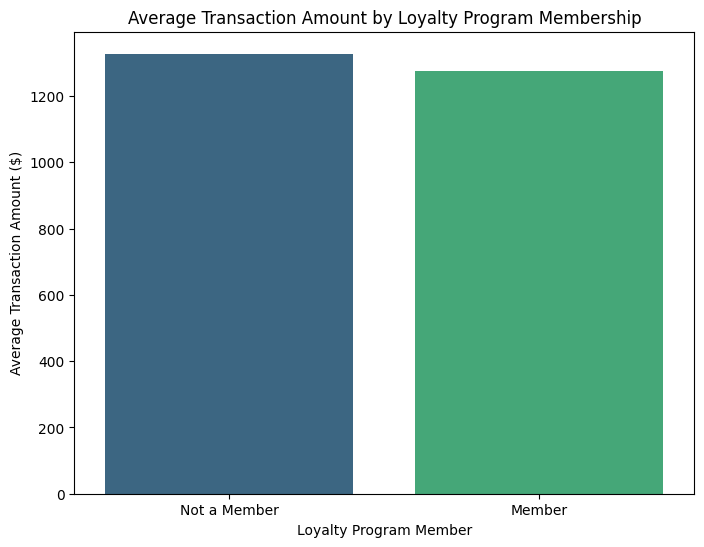

In [94]:
plt.figure(figsize=(8, 6))
sns.barplot(x=avg_transaction_by_loyalty.index, y=avg_transaction_by_loyalty.values, palette='viridis', hue=avg_transaction_by_loyalty.index, legend=False)
plt.title('Average Transaction Amount by Loyalty Program Membership')
plt.xlabel('Loyalty Program Member')
plt.ylabel('Average Transaction Amount ($)')
plt.xticks(ticks=[0, 1], labels=['Not a Member', 'Member'])
plt.show()

24. Identify customers who might be at risk of churning (e.g., `days_since_last_login` is high).


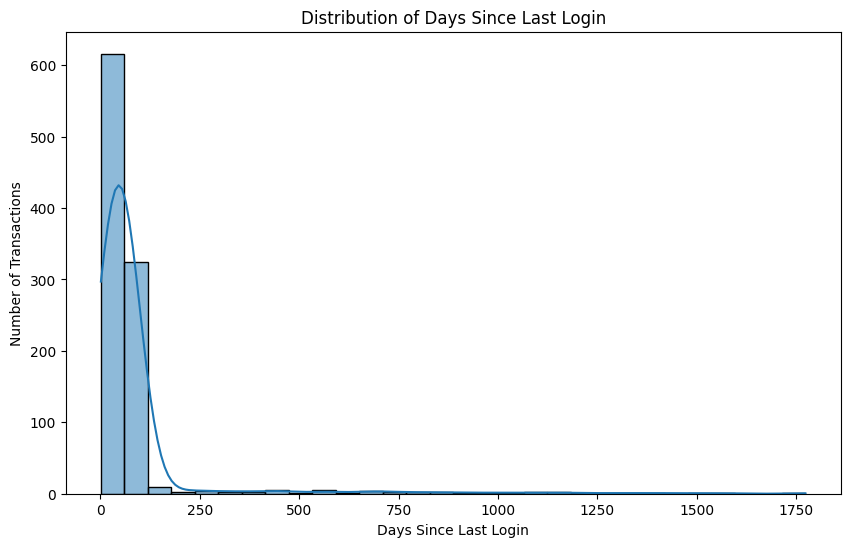

In [95]:
plt.figure(figsize=(10, 6))
sns.histplot(df['days_since_last_login'], bins=30, kde=True)
plt.title('Distribution of Days Since Last Login')
plt.xlabel('Days Since Last Login')
plt.ylabel('Number of Transactions')
plt.show()

In [96]:
churn_threshold = df['days_since_last_login'].quantile(0.75)

at_risk_transactions = df[df['days_since_last_login'] > churn_threshold]

at_risk_customers = at_risk_transactions['customer_id'].nunique()

print(f"Churn Risk Threshold (75th percentile of days_since_last_login): {churn_threshold:.2f} days")
print(f"Number of unique customers at risk of churning: {at_risk_customers}")
print(f"Average days since last login for at-risk customers: {at_risk_transactions['days_since_last_login'].mean():.2f} days")

Churn Risk Threshold (75th percentile of days_since_last_login): 72.25 days
Number of unique customers at risk of churning: 93
Average days since last login for at-risk customers: 210.70 days


25. Analyze the refund rate (`transaction_status` == 'Refunded') across different `product_category`s. Which categories have the highest refund rates?


In [96]:
1.